In [1]:
import numpy as np
import matplotlib.pyplot as plt
import ellc
import edmcmc as edm
import corner
import pandas as pd
from matplotlib import gridspec
from matplotlib.pyplot import cm
import batman
from astropy.io import ascii
import math
import os

from scipy.optimize import least_squares
from scipy.stats import linregress
import jax
import jax.numpy as jnp
from tinygp import GaussianProcess, kernels
import concurrent.futures
jax.config.update('jax_platforms', 'cpu')
import multiprocessing as mp
settings = np.seterr(over="ignore")


In [2]:
# adding noise to transit
def std_dev(arr_time):
    t_or_f = arr_time < -0.25
    arr_mask_1 = arr_time[t_or_f]
    masking2 = arr_time > 0.175
    arr_mask_2 = arr_time[masking2]

    # finding the values where the noise starts
    val1 = arr_mask_1[-1]
    val2 = arr_mask_2[0]

    # index where it occurs
    idx1 = np.where(arr_time == val1)
    idx2 = np.where(arr_time == val2)
    return idx1, idx2


def unpack_file(filepath):
    df = pd.read_csv(filepath, comment="#")
    for col in ("ccfjdsum", "ccfrvmod", "dvrms"):
        if col not in df.columns:
            raise ValueError(f"Input CSV missing required column: {col}")

    time_rv_unsort = df["ccfjdsum"].values.astype(float)  # times in days
    data_rv_unsort = df["ccfrvmod"].values.astype(float)  # observed RV in km/s
    err_rv_unsort = df["dvrms"].values.astype(float)  # RV uncertainties in km/s

    idx_1 = np.argsort(time_rv_unsort) #tinyGP requires sorted data
    time_rv = time_rv_unsort[idx_1]
    data_rv = data_rv_unsort[idx_1]
    err_rv = err_rv_unsort[idx_1]
    
    data_rv -= np.median(data_rv)
    return time_rv, data_rv, err_rv

def sma_star_units(sma, rstar):
    return (sma*rstar) #rstar in units of Rsun

In [3]:
#Transit (cleaned)
directory = '/home/nadja/Documents/UWMadison/Research/TOI5082/'

transit_file = ascii.read(directory+"tic437011608flattened-2min.csv")
time = transit_file["Time (BJD-2457000)"] 
transit_flux = transit_file["Flattened Flux"]
transit_time = time + 2457000


#RVs
first_rv = (directory + "NEID_TOI5082_RM_Event202502.csv")
second_rv = (directory + "2026-01-20_TOI5082.csv")

time_obs_1, rv_data_1_RAW, rv_err_1 = unpack_file(first_rv)
time_obs_2, rv_data_2_RAW, rv_err_2 = unpack_file(second_rv)


#mcmc
nlink = 75000
nburnin = 10000 
write_chains = True
thin_n = 20

In [37]:
#initial guesses
t0_bjd = 2459508.8190741274
rp_rs = (10 ** (-3) * 0.93**2) ** 0.5  # stellar radius units
sma = 11.8  #RATIO
RSTAR = 0.93
a_calc = sma_star_units(sma, RSTAR)
vsini = 7
lambda_guess = 0
incl = 87
r_1 = 1 / sma
r_2 = rp_rs * r_1
orbital_period = 4.2403567  # orbital_period
q_guess = 0.00002109

shape = 'sphere'
e_val = 0
periastron = 90
coef_1 = 0.1
coef_2 = 0.3

fs_guess = np.sqrt(e_val)*math.sin(np.deg2rad(periastron))
fc_guess  = np.sqrt(e_val)*math.cos(np.deg2rad(periastron))
p_star_guess = 1.743589

# GP initial guesses 
amplitude = 0.0005
scale = 0.03
labels=["a_over_R", "radius_planet", "vsini", "obliquity", "t0_trans", "incl", "period", 'fs', 'fc', 'c1', 'c2',  'amp', 'scale', 'slope_1', 'intercept_1', 'slope_2', 'intercept_2']


In [31]:
def systemic_offset(time, data, err):
    i_rad = np.radians(incl)
    rsum = (r_1 + r_2)
    val = rsum / max(1e-12, np.sin(i_rad))
    if val >= 1.0:
        transit_duration_days = 0.2
    else:
        transit_duration_days = orbital_period / np.pi * val
    transit_half_phase = (transit_duration_days / 2.0) / orbital_period

    phases_for_mask = ((time - t0_bjd) / orbital_period + 0.5) % 1.0 - 0.5 #change
    in_transit_mask = np.abs(phases_for_mask) < transit_half_phase
    out_of_transit_mask = ~in_transit_mask

    if out_of_transit_mask.sum() < 3:
        out_of_transit_mask = np.ones_like(out_of_transit_mask, dtype=bool)
    weights = 1.0 / (err**2) #change

    gamma_weighted = np.sum(weights[out_of_transit_mask] * data[out_of_transit_mask]) / np.sum(weights[out_of_transit_mask]) #change
    data = data - gamma_weighted #change
    return data

rv_data_1 = systemic_offset(time_obs_1, rv_data_1_RAW, rv_err_1)
rv_data_2 = systemic_offset(time_obs_2, rv_data_2_RAW, rv_err_2)

#TESS standard dev
phase_trans = ((transit_time - t0_bjd) / orbital_period) - np.round(
    (transit_time - t0_bjd) / orbital_period
)

i, j = std_dev(phase_trans)

idx1 = i[0][0]
idx2 = j[0][0]

noise_arr = np.concatenate((transit_flux[:idx1], transit_flux[idx2:]), axis=0)
error = np.nanstd(noise_arr)
trans_err = np.full_like(transit_flux, error)

## bg trend
def lin_trend(time, data):
    time_centered = time - np.median(time)
    slope, intercept, r_val, p_val, std_err = linregress(time_centered, data)
    return slope, intercept

#linear background trend
slope_1, intercept_1 = lin_trend(time_obs_1, rv_data_1)
slope_2, intercept_2 = lin_trend(time_obs_2, rv_data_2)

In [32]:
# Gaussian Process
def build_gp(params, time):
    kernel = kernels.quasisep.Matern32(scale=jnp.exp(params['log_scale']), sigma=jnp.exp(params['log_amp']))
    return GaussianProcess(kernel, time, diag=jnp.exp(params["log_diag"]))

In [33]:
def lnprior(p):
    r_star_sma, rplanet, vsini_guess, obliquity, t0_trans, inc, period, fs, fc, c_1, c_2, amp, scale, a, c, m, d  = p
    r_1 = 1/r_star_sma
    r_2 = r_1 * rplanet
    if t0_trans < t0_bjd - 1 or t0_trans >  t0_bjd+1:
        return -np.inf
    '''if period > orbital_period + 0.0001 or period < orbital_period - 0.0001:
        return -np.inf
    if (r_1+r_2) > 1 or (r_1+r_2) < 0:
        return -np.inf'''
    if rplanet <= 0 or rplanet >= 1:
        return -np.inf
    if inc < 0 or inc > 90:
        return -np.inf
    if fs <=-1 or fs >= 1:
        return -np.inf
    if fc <=-1 or fc >= 1:
        return -np.inf
    if c_1 > 1 or c_1 <0:
        return -np.inf
    if c_2 > 1 or c_2 < 0:
        return -np.inf
    if obliquity > 180 or obliquity < -180:
        return -np.inf
    if vsini_guess < 0 or vsini_guess > 20:
        return -np.inf
    w_peri = np.arctan2(fs, fc)
    ecc = fs**2 +fc**2
    if ecc >=0.975:
        return -np.inf
    if not np.isfinite(ecc):
        return -np.inf
    b = np.abs(r_star_sma * np.cos(np.deg2rad(inc)) * (1-ecc**2)/(1+ecc*np.sin(w_peri)))
    if b < 0 or b > 1:
        return -np.inf
    if amp < 0:
        return -np.inf
    if scale < 0:
        return -np.inf
    '''if not (-0.5 < a < 0.5): return -np.inf
    if not (-0.5 < m < 0.5): return -np.inf'''

    p_star = (3 * np.pi * pow(r_star_sma,3))/(497.582 * period**2)

    mu_p_star = 1.743589  # yea change this
    sigma_p = 0.1

    # Calculate individual priors
    prior_pstar = (
        np.log(1.0 / (np.sqrt(2 * np.pi) * sigma_p))
        - 0.5 * (p_star - mu_p_star) ** 2 / sigma_p**2
    )
    return prior_pstar


In [63]:
def trans_loglikelihood(p, trans_time, trans_obs, err):
    r_star_sma, rplanet, vsini_guess, obliquity, t0_trans, inc, period, fs, fc, c_1, c_2= p
    ecc = fs **2 + fc **2 
    w_peri = np.arctan2(fs, fc)

    batman_params = batman.TransitParams()
    batman_params.t0 = t0_trans # time of inferior conjunction
    batman_params.rp = rplanet  # planet radius (in units of stellar radii)
    batman_params.a = r_star_sma  # semi-major axis (in units of stellar radii)
    batman_params.inc = inc  # orbital inclination (in degrees)
    batman_params.per = period  # orbital period
    batman_params.ecc = ecc  # eccentricity

    batman_params.w = np.rad2deg(w_peri)  # longitude of periastron (in degrees)
    batman_params.u = [c_1, c_2]  # limb darkening coefficients [u1, u2]
    batman_params.limb_dark = "quadratic"  # limb darkening model

    try: 
        m = batman.TransitModel(batman_params, trans_time)
        model = m.light_curve(batman_params)
    except Exception:
        return -np.inf
    
    norm = np.sum(np.log(2*np.pi*err**2))
    chisq = np.sum((trans_obs - model) ** 2 / err**2)

    trans_loglikelihood = -0.5 * (chisq+norm)
    return trans_loglikelihood

def rv_loglikelihood(p, trend, time, rv_obs, rv_err, yesplot=False):

    (r_star_sma, rplanet, vsini_guess, obliquity, t0_trans, inc, 
     period, fs, fc, c_1, c_2, amp, scale_val) = p
    (slope_m, intercept) = trend
    r1 = 1 / r_star_sma
    r2 = rplanet * r1
    ## GP inclusion

    semi_major_axis = sma_star_units(r_star_sma, RSTAR)
    rv_model, _ = ellc.rv(
        time,
        t_zero=t0_trans,
        period=period,
        lambda_1=obliquity,
        radius_1=r1,
        radius_2=r2,
        incl=inc,
        f_s=fs,
        f_c=fc,
        a=semi_major_axis,
        shape_1="sphere",
        shape_2="sphere",
        vsini_1=vsini_guess,
        flux_weighted=True,
        sbratio=0,
        q=q_guess,
        verbose=0
        )
    
    time_centered = time - np.median(time)
    model_slope = slope_m * time_centered + intercept

    base = rv_model + model_slope
    #norm = np.sum(np.log(2*np.pi*rv_err**2))
    #chisq = np.sum((rv_obs - base) ** 2 / rv_err**2)

    #call gp func instead of of loglikelihood
    theta = {
    "log_amp": jnp.log(amp),    
    "log_scale": jnp.log(scale_val),      
    "log_diag": jnp.log(rv_err**2)} 

    gp = build_gp(theta, time_centered) #might b wrong
    cond_gp = gp.condition(rv_obs, time_centered).gp
    mu, var = cond_gp.loc, cond_gp.variance
    logl = gp.log_probability((rv_obs - base))
    
    #rv_loglikelihood = -0.5 * (chisq+norm)
    if yesplot:
        #print(theta)
        plt.errorbar(time, rv_obs, yerr = rv_err, label='data', fmt='o')
        plt.plot(time, base, 'o-', label='model')
        plt.plot(time, mu+base, 'o-', label='gp+model')
        plt.plot(time, mu, 'o-', label='gp')
        plt.legend()
        plt.show()
    return logl

In [64]:
def lnprob(p, time_rv, time_rv_2, time_trans, rv_obs_1, rv_obs_2, trans_obs, rv_err_1, rv_err_2, trans_err, yesplot=False):
    penal_pstar = lnprior(p)
    if not np.isfinite(penal_pstar):
        return -np.inf
    p_orbit = p[0:11]    
    p_rv = p[0:13] 
    a, c, b, d = p[13:17] 
    
    rv_logp_1 = rv_loglikelihood(p_rv, (a, c), time_rv, rv_obs_1, rv_err_1, yesplot=yesplot) 
    if not np.isfinite(rv_logp_1):
        return -np.inf
        
    rv_logp_2 = rv_loglikelihood(p_rv, (b, d), time_rv_2, rv_obs_2, rv_err_2, yesplot=yesplot) 
    if not np.isfinite(rv_logp_2):
        return -np.inf
        
    trans_logp = trans_loglikelihood(p_orbit, time_trans, trans_obs, trans_err)
    if not np.isfinite(trans_logp):
        return -np.inf
    
    total_logp = rv_logp_1 + trans_logp + penal_pstar + rv_logp_2
    return (float(total_logp))


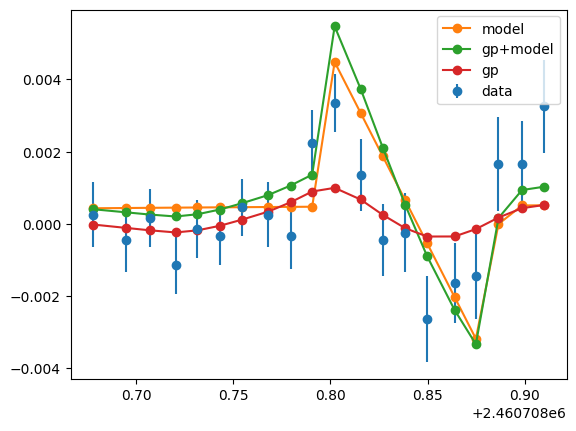

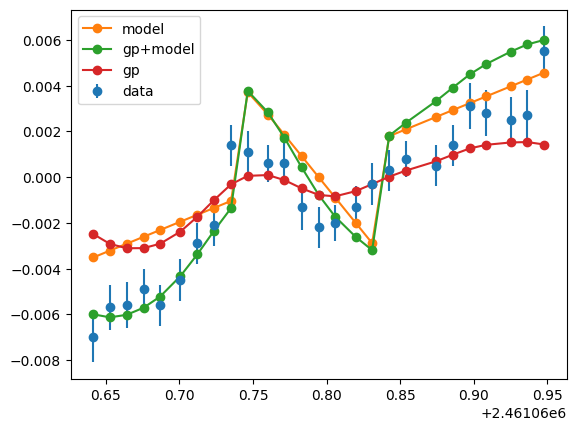

In [65]:
p0 = [sma, rp_rs, vsini, lambda_guess, t0_bjd, incl, orbital_period, fs_guess, fc_guess, coef_1, coef_2, amplitude, scale, slope_1, intercept_1, slope_2, intercept_2]

debug = lnprob(p0, time_obs_1, time_obs_2, transit_time, 
    rv_data_1_RAW, rv_data_2_RAW, transit_flux, 
    rv_err_1, rv_err_2, trans_err, yesplot=True)

In [66]:
amp_arr = np.linspace(0, 0.005, 10)
scale_arr = np.linspace(0.00001, 0.21, 10)
log_lh_scale = []

In [57]:
print(scale_arr)

[1.00000000e-05 2.33422222e-02 4.66744444e-02 7.00066667e-02
 9.33388889e-02 1.16671111e-01 1.40003333e-01 1.63335556e-01
 1.86667778e-01 2.10000000e-01]


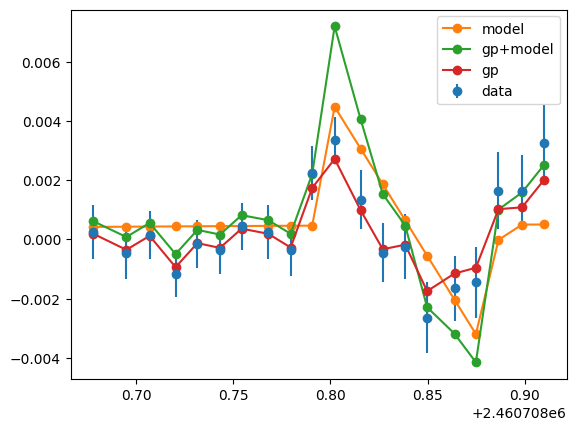

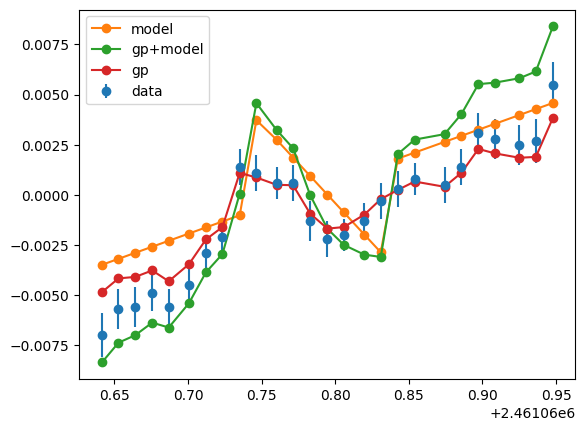

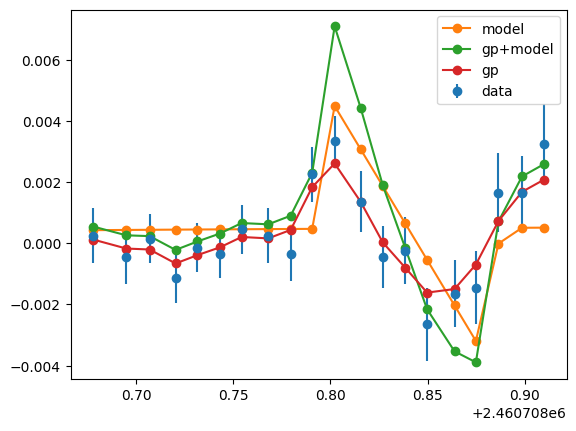

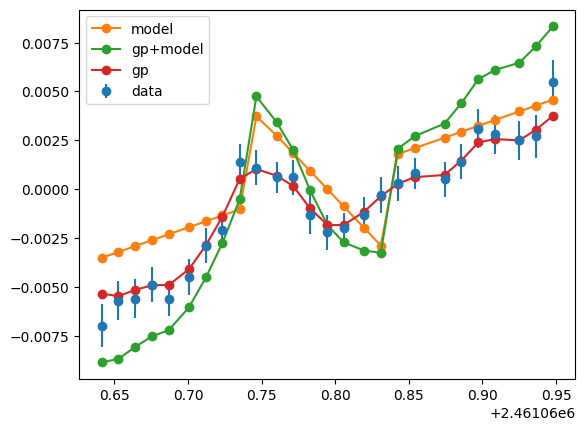

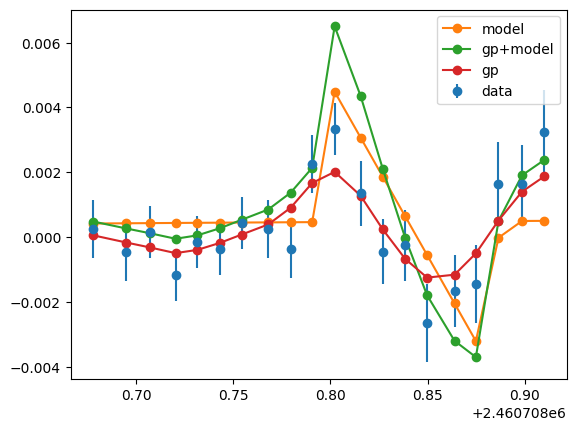

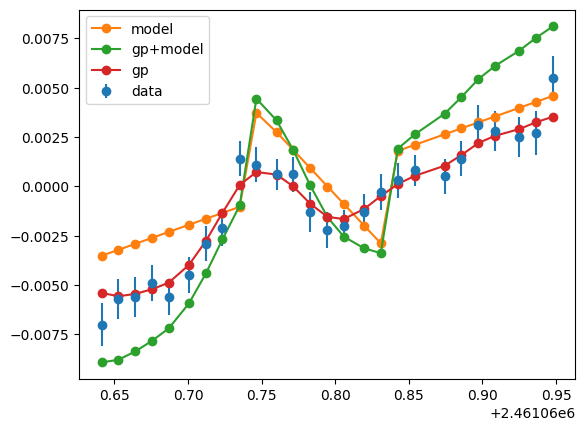

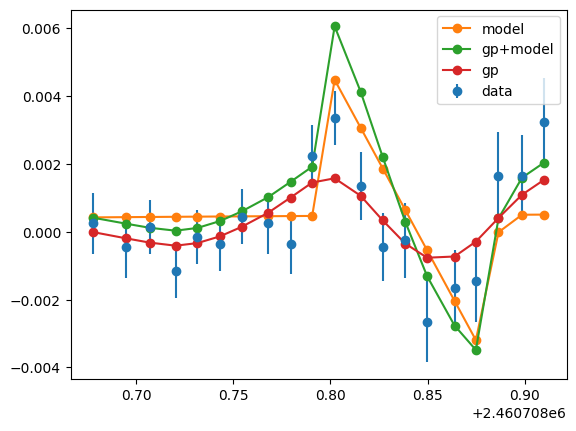

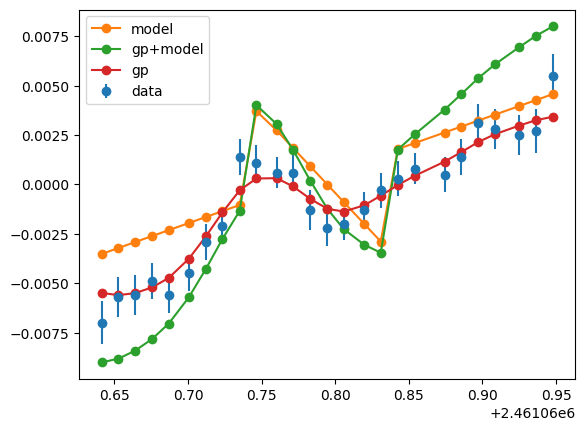

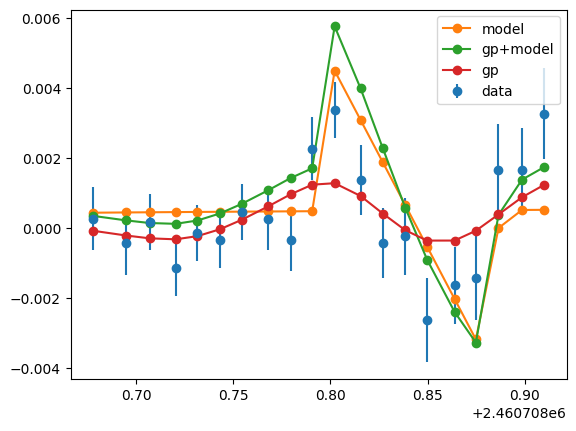

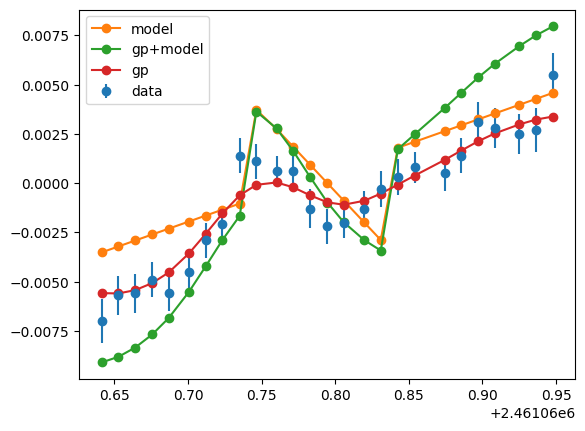

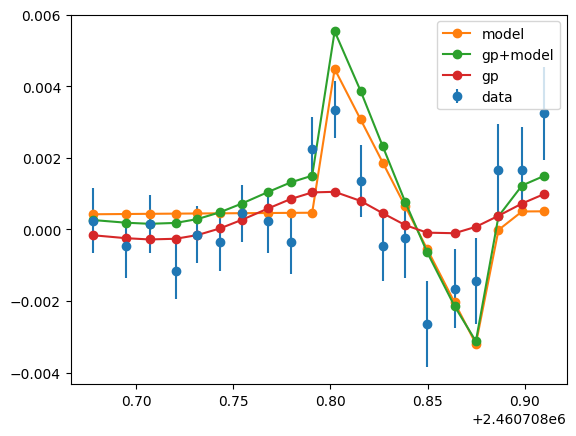

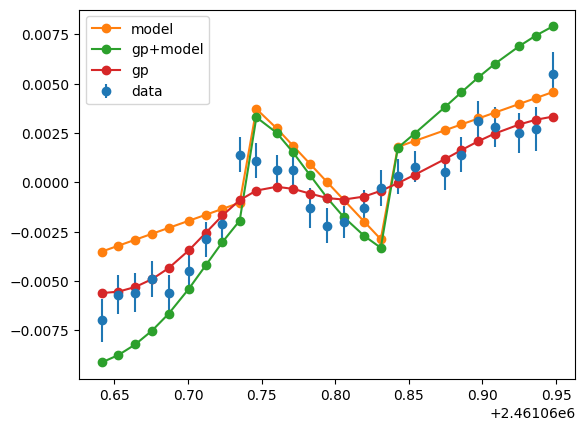

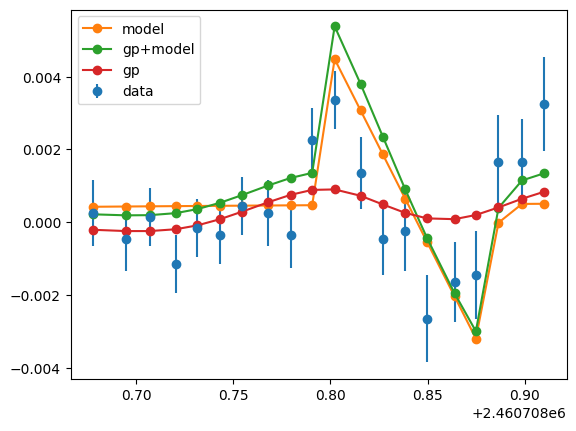

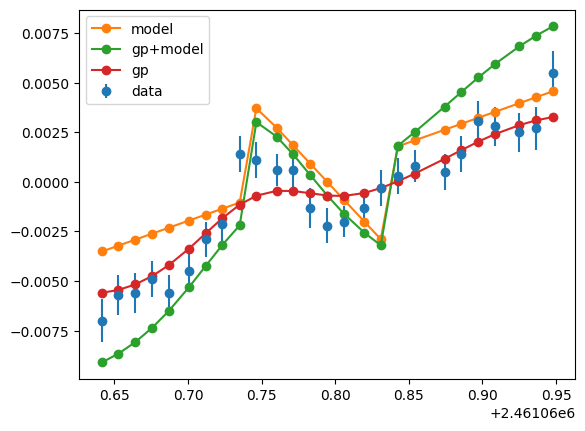

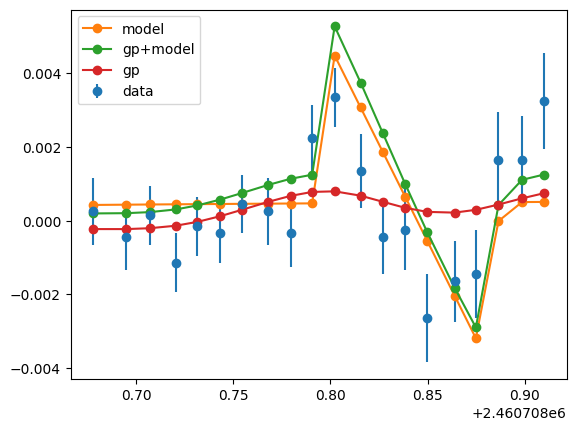

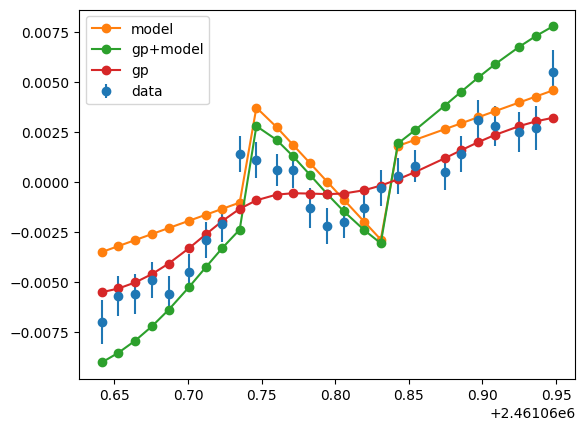

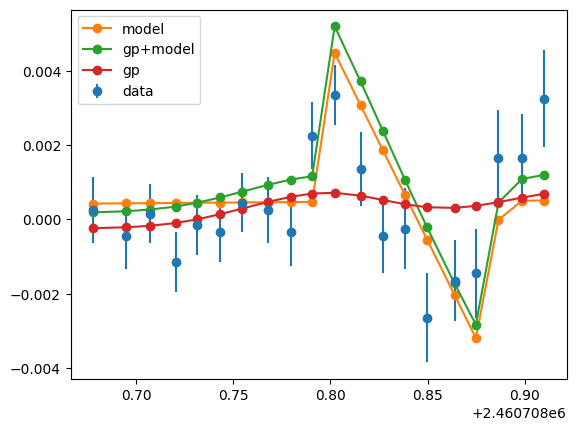

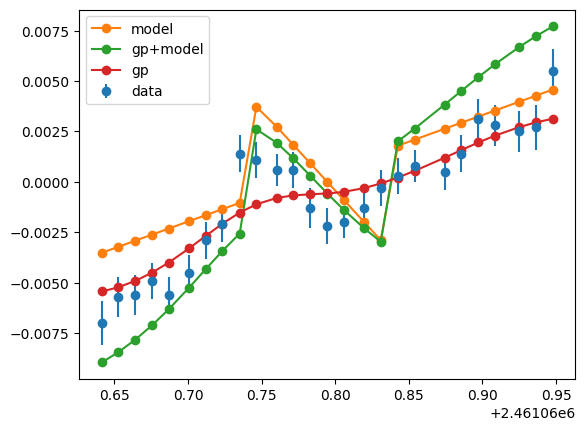

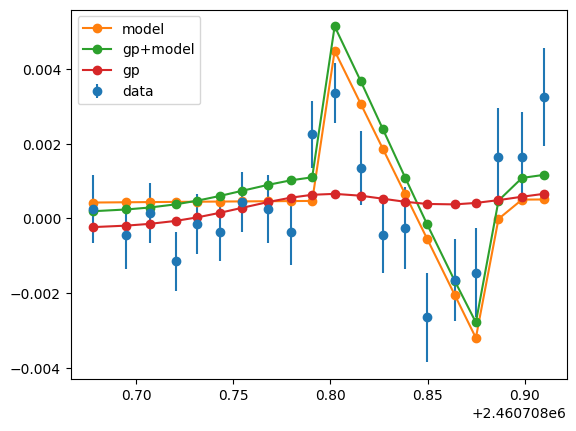

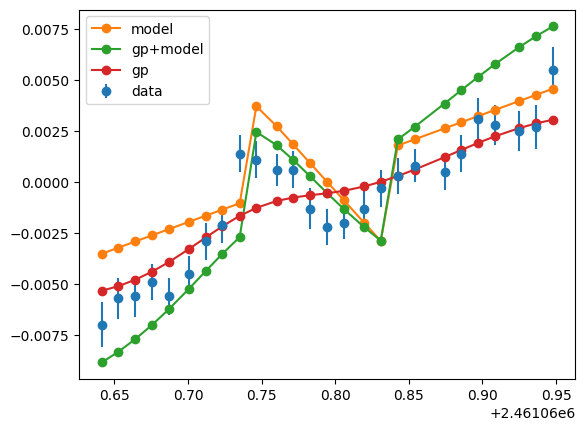

In [67]:
for i in range(len(scale_arr)):
    p0 = [sma, rp_rs, vsini, lambda_guess, t0_bjd, incl, orbital_period, fs_guess, fc_guess, coef_1, coef_2, 0.00166667, scale_arr[i], slope_1, intercept_1, slope_2, intercept_2]

    debug = lnprob(p0, time_obs_1, time_obs_2, transit_time, 
        rv_data_1_RAW, rv_data_2_RAW, transit_flux, 
        rv_err_1, rv_err_2, trans_err, yesplot=True)

    log_lh_scale.append(debug)

Text(0, 0.5, 'lnprob-result')

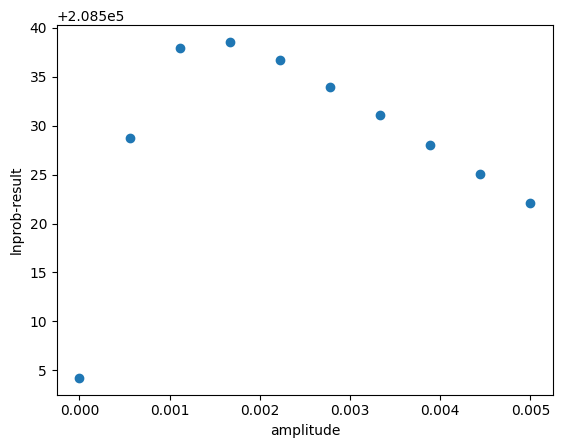

In [61]:
plt.scatter(amp_arr, log_lh)
plt.xlabel('amplitude')
plt.ylabel('lnprob-result')

In [ ]:
print(log_lh)


[208504.21875, 208528.703125, 208537.953125, 208538.5625, 208536.6875, 208534.0, 208531.046875, 208528.03125, 208525.046875, 208522.125]


Text(0, 0.5, 'lnprob-results')

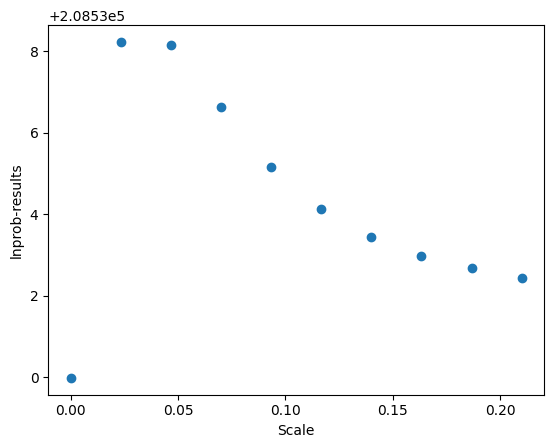

In [62]:
plt.scatter(scale_arr, log_lh_scale, label = 'Scale variation')
plt.xlabel('Scale')
plt.ylabel('lnprob-results')